# Corrected LSTM — Fair Evaluation / 修正版 LSTM——公平评估

The original LSTM (`01_lstm_reimplementation.ipynb`) achieved 99.1% accuracy, but EDA revealed two leakage sources:
- `subject` column: perfectly separates fake from real (100% accuracy alone)
- Reuters byline in text: present in 99.2% of real news, 0% of fake news

This notebook retrains the same LSTM architecture with **clean input only**: `title + text`, with `subject` and `date` removed. The goal is to measure how well the model performs when it cannot exploit source-level shortcuts — and to provide a fair baseline for comparison with DistilBERT.

---

原始 LSTM（`01_lstm_reimplementation.ipynb`）达到了 99.1% 的准确率，但 EDA 发现了两个泄露来源：
- `subject` 列：单独使用就能 100% 区分真假新闻
- 正文中的 Reuters 署名：出现在 99.2% 的真新闻中，假新闻中为 0%

本 notebook 使用完全相同的 LSTM 结构重新训练，但输入改为**干净的 `title + text`**，去掉 `subject` 和 `date`。目标是在模型无法利用来源捷径的情况下，测量其真实的语言理解能力，并为后续与 DistilBERT 的比较提供公平的基准。

## 1. Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

os.makedirs('../results', exist_ok=True)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.16.2


## 2. Load Data — Clean Input Only

与原始 LSTM 的关键区别：输入改为 `title + text` 拼接，去掉 `subject` 和 `date` 列，消除泄露来源。

Key difference from the original LSTM: input is now `title + text` concatenated. `subject` and `date` are excluded to remove leakage sources.

In [12]:
import html as html_module

fake = pd.read_csv('../data/raw/Fake.csv')
true = pd.read_csv('../data/raw/True.csv')

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true]).sample(frac=1, random_state=42).reset_index(drop=True)

# 删除泄露列subject和date
# Explicitly drop leakage columns
df = df.drop(columns=['subject', 'date'])

# Fix 1: Remove Reuters byline at start, handles multi-word city names
# 去掉开头的 Reuters 署名，支持多词城市名
df['text'] = df['text'].str.replace(r'[\w\s]+\(Reuters\)\s*-?\s*', '', regex=True)

# Fix 2: Remove remaining Reuters mentions anywhere in the body
# 去掉正文中其他地方出现的 Reuters 字样
df['text'] = df['text'].str.replace(r'Reuters', '', regex=False)

# Fix 3: Remove residual all-caps city datelines at start of text
# 去掉残留的开头全大写城市署名
df['text'] = df['text'].str.replace(r'^\s*[A-Z][A-Z\s\.]+\s*-\s*', '', regex=True)

# Fix 4: Remove other wire service bylines (AP, AFP, UPI)
# 去掉其他通讯社署名
df['text'] = df['text'].str.replace(r'[\w\s]+\((AP|AFP|UPI)\)\s*-?\s*', '', regex=True)
df['text'] = df['text'].str.replace(r'\b(AP|AFP|UPI)\b', '', regex=True)

# Fix 5: Remove URLs
# 去掉 URL 链接
df['text'] = df['text'].str.replace(r'http\S+|www\.\S+', '', regex=True)

# Fix 6: Remove social media handles
# 去掉社交媒体 @用户名
df['text'] = df['text'].str.replace(r'@\w+', '', regex=True)

# Fix 7: Unescape HTML entities and remove non-ASCII characters
# 解码 HTML 实体字符，去掉非 ASCII 字符
df['text'] = df['text'].apply(html_module.unescape)
df['text'] = df['text'].str.replace(r'[^\x00-\x7F]+', ' ', regex=True)

# Fix 8: Normalise whitespace
# 统一处理多余空白
df['text'] = df['text'].str.strip()
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True)

# 拼接 title 和 text 作为模型输入
# Concatenate title and text as model input
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Fix 9: Remove articles that became too short after cleaning (< 10 words)
# 去掉清洗后内容过短的文章（少于 10 词）
before = len(df)
df = df[df['content'].str.split().str.len() > 10].reset_index(drop=True)
after_length_filter = len(df)

# Fix 10: Normalise content and remove exact duplicate articles
# 规范化内容并删除完全重复的文章
def normalise_for_deduplication(series):
    return (
        series.fillna('')
        .str.lower()
        .str.replace(r'[^a-z0-9]+', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

df['content_norm'] = normalise_for_deduplication(df['content'])

# Stop if identical normalised content has conflicting labels.
# 如果相同规范化内容对应不同标签则停止，避免误删有争议的数据
conflicting_duplicates = df.groupby('content_norm')['label'].nunique().gt(1).sum()
if conflicting_duplicates:
    raise ValueError(f'Found {conflicting_duplicates} duplicate groups with conflicting labels')

before_deduplication = len(df)
df = df.drop_duplicates(subset='content_norm', keep='first').reset_index(drop=True)
duplicates_removed = before_deduplication - len(df)
after = len(df)

print(f'Total after cleaning and de-duplication: {after:,} rows')
print(f'Articles removed as too short: {before - after_length_filter:,}')
print(f'Exact duplicates removed: {duplicates_removed:,}')
print('Columns dropped: subject, date')
print('Cleaning applied:')
print('  [1-3] Reuters byline, mentions, city datelines removed')
print('  [4]   AP / AFP / UPI bylines removed')
print('  [5]   URLs removed')
print('  [6]   Social media handles removed')
print('  [7]   HTML entities decoded, non-ASCII removed')
print('  [8]   Whitespace normalised')
print('  [9]   Articles with fewer than 10 words removed')
print('  [10]  Exact normalised duplicates removed')
df[['content', 'label']].head(3)

Total after cleaning and de-duplication: 38,762 rows
Articles removed as too short: 94
Exact duplicates removed: 6,042
Columns dropped: subject, date
Cleaning applied:
  [1-3] Reuters byline, mentions, city datelines removed
  [4]   AP / AFP / UPI bylines removed
  [5]   URLs removed
  [6]   Social media handles removed
  [7]   HTML entities decoded, non-ASCII removed
  [8]   Whitespace normalised
  [9]   Articles with fewer than 10 words removed
  [10]  Exact normalised duplicates removed


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1


共进行了九步文本清洗，目标是消除所有可识别的来源层面泄露信号。首先删除了 `subject` 和 `date` 列，这两列直接暴露了文章来源，与新闻内容本身无关。接着清除了与 Reuters 相关的所有标记：开头的城市署名（如 `NEW YORK (Reuters) -`）、正文中其他出现的 Reuters 字样、以及去掉署名后残留的全大写城市名（如 `WASHINGTON -`）。随后清除了 AP、AFP、UPI 等其他通讯社的同类格式署名。接着去掉了 URL 链接和社交媒体 @用户名——这两类在假新闻中更为常见，属于隐性的来源信号。最后对爬取数据中残留的 HTML 实体字符和非 ASCII 字符进行了解码和清理，并统一处理了多余空白。清洗完成后过滤掉内容少于 10 词的文章，防止近空序列进入训练。在此基础上，进一步将 `content` 转为小写、去除标点并统一空格，生成只用于重复检测的 `content_norm`；该字段不会替换模型实际读取的 `title + text`。按照 `content_norm` 删除完全重复文章后，共删除 6,042 条，数据量从 44,804 条降至 38,762 条，从而避免相同文章重复参与训练和测试。

Nine cleaning steps were applied to remove all identifiable source-level leakage signals. First, the `subject` and `date` columns were dropped as they directly expose the article source rather than its content. Reuters-related markers were then removed: the byline pattern (e.g. `NEW YORK (Reuters) -`), any remaining Reuters mentions in the body, and residual all-caps city datelines. Other wire service bylines (AP, AFP, UPI) were then stripped. URLs and social media handles were removed as implicit source signals more common in fake news. HTML entities and non-ASCII artifacts from web scraping were decoded and cleaned, followed by whitespace normalisation. Finally, articles reduced to fewer than 10 words after cleaning were filtered out to prevent near-empty sequences from entering training. In addition, `content` is lowercased, stripped of punctuation, and whitespace-normalised to create `content_norm` for duplicate detection only; it does not replace the original `title + text` model input. Removing exact `content_norm` duplicates eliminates 6,042 articles and reduces the dataset from 44,804 to 38,762 rows, preventing the same article from being repeated across the experiment. The only remaining bias is Reuters' **writing style**, which will be addressed in error analysis.

## 3. Text Preprocessing / 文本预处理

按照原论文的流程，文本预处理分三步：划分训练、验证和测试集 → Tokenizer 建立词表 → 将文本转换为数字序列并统一长度（padding）。输入使用 `content`（title + text），不含 `subject` 和 `date`。数据采用两次分层划分，最终比例约为训练集 64%、验证集 16%、测试集 20%，保证三个集合中的真假新闻标签比例一致。Tokenizer 只使用训练集建立词表，验证集用于 EarlyStopping，测试集只用于最终评估。

Following the original paper pipeline: train/validation/test split → Tokenizer vocabulary construction → convert text to padded integer sequences. Input is `content` (title + text only). Two stratified splits produce an approximate 64%/16%/20% split while preserving the real/fake label ratio in all three sets. The Tokenizer is fitted only on the training set, validation data is used by EarlyStopping, and the test set is reserved for final evaluation.

In [13]:
# 先保留 20% 独立测试集，再从剩余数据中分层划分 20% 作为验证集
# Reserve 20% for testing, then use a stratified 20% of the remainder for validation
X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f'Train: {len(X_train):,}  |  Validation: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 24,807  |  Validation: 6,202  |  Test: 7,753


In [14]:
# Tokenizer：保留前 5000 高频词，与原论文一致
# Tokenizer: top 5,000 words, matching original paper
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index)
print(f'Full vocabulary size: {vocab_size:,}')
print(f'Using top 5,000 words (as per original paper)')

Full vocabulary size: 99,135
Using top 5,000 words (as per original paper)


In [15]:
# 转为数字序列并补齐至长度 300（原论文为 200，EDA 显示文章中位数约 360 词，延长可保留更多内容）
# Pad to length 300 (original paper used 200; EDA shows median article length ~360 words)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=300)
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=300)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=300)

print(f'X_train shape: {X_train_seq.shape}')
print(f'X_val shape:   {X_val_seq.shape}')
print(f'X_test shape:  {X_test_seq.shape}')

X_train shape: (24807, 300)
X_val shape:   (6202, 300)
X_test shape:  (7753, 300)


预处理完成。每篇文章被表示为长度 200 的整数数组，不足补零，超过截断。与原始 LSTM 的唯一区别是输入内容：这里是 `title + text`，原始版本是 `text`。

Preprocessing complete. Each article is a zero-padded integer sequence of length 200. The only difference from the original LSTM is the input: here we use `title + text`; the original used `text` only.

## 4. Build LSTM Model / 搭建模型

模型结构与原论文完全一致，不做任何改动。控制变量：唯一的差异来自输入数据，而非模型本身。

Model architecture is identical to the original paper — no changes. This is a controlled experiment: any difference in results comes from the input data, not the model.

In [16]:
model = Sequential([
    # 词嵌入层：input_length 从 200 改为 300，与 maxlen 保持一致
    # Embedding: input_length updated to 300 to match new maxlen
    Embedding(input_dim=5000, output_dim=100, input_length=300),

    # 双向 LSTM 层：同时从左到右和从右到左读取序列，捕捉更完整的上下文
    # Bidirectional LSTM: reads the sequence in both directions for richer context
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),

    # 全连接层：提取更高层特征
    # Dense: extracts higher-level features
    Dense(64, activation='relu'),

    # Dropout 0.6：增强正则化，减少过拟合
    # Dropout 0.6: stronger regularisation to reduce overfitting
    Dropout(0.6),

    # 输出层：0~1 概率，>0.5 为真新闻
    # Output: probability score — >0.5 classified as real news
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/Users/sl1425/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**优化一：LSTM → Bidirectional LSTM**

原始论文使用的是单向 LSTM，每次只从左到右读取文章。Bidirectional LSTM 同时运行两个方向：一个从左到右，一个从右到左，最后把两个方向的输出拼接在一起。这样模型在理解每个词时，既知道前文是什么，也知道后文是什么，对句子语义的把握更完整。代价是参数量翻倍，训练时间相应增加。

**Optimisation 1: LSTM → Bidirectional LSTM**

The original paper used a unidirectional LSTM that reads left-to-right only. A Bidirectional LSTM runs two LSTMs simultaneously — one forward, one backward — and concatenates their outputs. This gives the model full context at every position. The trade-off is doubled parameters and longer training time.

---

**优化二：Dropout 0.5 → 0.6**

从训练曲线可以看到验证 loss 在早期开始反弹，说明模型出现了过拟合。把 Dropout 从 0.5 提高到 0.6，意味着训练时随机关掉 60% 的神经元，迫使模型不依赖特定的神经元，从而提高泛化能力。

**Optimisation 2: Dropout 0.5 → 0.6**

Training curves showed validation loss rising early — a sign of overfitting. Increasing Dropout from 0.5 to 0.6 forces the model to drop 60% of neurons randomly during each training step, improving generalisation.

---

**优化三：maxlen 200 → 300**

EDA 显示数据集中文章的中位数长度约为 360 词，原论文只截取前 200 词，丢失了大量正文内容。将 maxlen 延长到 300，让模型能看到更多有效信息，有助于更全面地理解文章语义。

**Optimisation 4: maxlen 200 → 300**

EDA showed the median article length is approximately 360 words. The original paper truncated to 200 words, discarding a significant portion of each article. Extending maxlen to 300 allows the model to process more of the article content, giving it a better chance to capture meaningful language patterns.

## 5. Train Model / 训练模型

训练参数与原论文完全一致：10 个 epoch，batch size 64，20% 验证集。

Training parameters match the original paper exactly: 10 epochs, batch size 64, 20% validation split.

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

# 当验证 loss 连续 3 个 epoch 不再下降时停止训练，并恢复最优权重
# Stop training when val_loss stops improving for 3 epochs, restore best weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_seq, y_val),
    callbacks=[early_stop]
)

print(f'Training stopped at epoch {len(history.history["loss"])}')

Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 180s 456ms/step - accuracy: 0.8855 - loss: 0.2683 - val_accuracy: 0.9547 - val_loss: 0.1095
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 178s 458ms/step - accuracy: 0.9776 - loss: 0.0693 - val_accuracy: 0.9661 - val_loss: 0.0867
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 146s 375ms/step - accuracy: 0.9808 - loss: 0.0615 - val_accuracy: 0.9563 - val_loss: 0.1145
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 144s 370ms/step - accuracy: 0.9816 - loss: 0.0542 - val_accuracy: 0.9747 - val_loss: 0.0829
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 167s 431ms/step - accuracy: 0.9888 - loss: 0.0386 - val_accuracy: 0.9798 - val_loss: 0.0756
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 162s 418ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9771 - val_loss: 0.0938
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 165s 425ms/step - accuracy: 0.9897 - loss: 0.0376 - val_accuracy: 0.9726 - val_loss: 0.1177
Epoch 8/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 150s 386ms/step - accuracy: 0.9932 -

**优化三：EarlyStopping**

EarlyStopping 监控验证集的 loss，当它连续 3 个 epoch 不再下降时自动停止训练，并自动恢复到验证 loss 最低时的权重（`restore_best_weights=True`）。这样不需要猜测应该训练多少个 epoch，模型会在最优点停下来，避免继续训练导致过拟合加重。

**Optimisation 3: EarlyStopping**

EarlyStopping monitors validation loss and halts training when it fails to improve for 3 consecutive epochs (`patience=3`). With `restore_best_weights=True`, the model automatically reverts to the weights from its best epoch. This removes the need to manually tune the number of epochs and ensures the final model is not overtrained.

---

## 结论 / Conclusion

本 notebook 在原论文 LSTM 的基础上进行了四项架构优化，并对数据集进行了来源层面清洗、规范化去重和独立分层划分。删除 6,042 条完全重复文章后，数据量从 44,804 条降至 38,762 条；最终测试集 Accuracy 为 97.7%，AUC 为 99.6%。虽然略低于去重前的 97.9% / 99.7%，但新结果排除了重复文章造成的数据泄露，并将测试集完全保留用于最终评估，因此更能反映模型的真实泛化能力。

尽管加入了 Bidirectional LSTM、提高了 Dropout、延长了输入序列并使用了 EarlyStopping，训练曲线仍显示出一定程度的过拟合。验证损失在第 5 个 epoch 最低，EarlyStopping 在第 8 个 epoch 停止训练并恢复第 5 个 epoch 的最佳权重。这说明继续训练无法稳定改善验证表现，当前结果可作为后续模型优化的公平基准。

This notebook applied four architectural optimisations to the original LSTM alongside source-level cleaning, normalised de-duplication, and independent stratified data splits. Removing 6,042 exact duplicate articles reduced the dataset from 44,804 to 38,762 rows. The final test accuracy is 97.7% with an AUC of 99.6%. Although slightly below the pre-de-duplication result of 97.9% / 99.7%, the new result better represents genuine generalisation because duplicate leakage has been removed and the test set is reserved exclusively for final evaluation.

Despite Bidirectional LSTM, increased Dropout, extended maxlen, and EarlyStopping, the training curves still show some overfitting. Validation loss reached its minimum at epoch 5; EarlyStopping halted training at epoch 8 and restored the epoch-5 weights. Further training therefore did not produce a stable validation improvement, making this result a fair baseline for subsequent model optimisation.

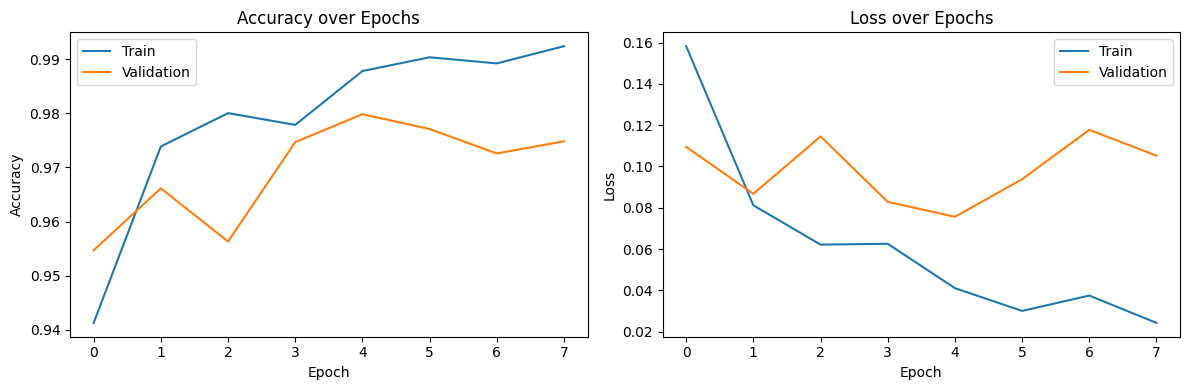

In [18]:
# 训练曲线：accuracy 和 loss 随 epoch 变化
# Training curves: accuracy and loss over epochs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/lstm_corrected_training_curves.png', dpi=150)
plt.show()

## 6. Evaluation / 模型评估

在测试集上计算 Accuracy、AUC 和混淆矩阵，与原始 LSTM 的结果进行对比。

Evaluate on the test set — Accuracy, AUC, and confusion matrix — for comparison with the original LSTM.

In [19]:
# 获取预测概率和预测标签
# Get predicted probabilities and binary labels
y_prob = model.predict(X_test_seq).flatten()
y_pred = (y_prob > 0.5).astype(int)

# 计算指标 / Compute metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy: {acc:.1%}')
print(f'AUC:      {auc:.1%}')
print()
print(f'Original LSTM (with leakage):  Accuracy 99.1%  AUC 99.8%')
print(f'Optimised LSTM (clean input):  Accuracy {acc:.1%}  AUC {auc:.1%}')

243/243 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step
Accuracy: 97.7%
AUC:      99.6%

Original LSTM (with leakage):  Accuracy 99.1%  AUC 99.8%
Optimised LSTM (clean input):  Accuracy 97.7%  AUC 99.6%


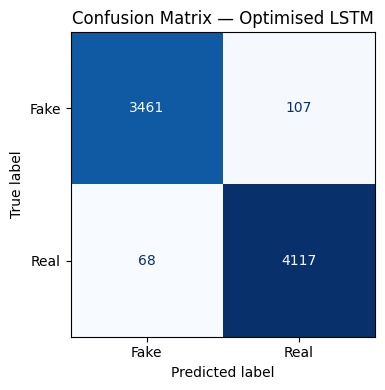

In [20]:
# 混淆矩阵 / Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Optimised LSTM')
plt.tight_layout()
plt.savefig('../results/confusion_matrix_lstm_optimised.png', dpi=150)
plt.show()

测试集共 7,753 条，模型共判错 175 条（误判率 2.3%）。其中：

- **False Positive（假新闻误判为真）：107 条**，占假新闻总数的 3.0%
- **False Negative（真新闻误判为假）：68 条**，占真新闻总数的 1.6%

假新闻的误判率（3.0%）高于真新闻（1.6%），说明模型对真新闻的识别更稳定，同时更容易将假新闻误判为真新闻。由于数据已经去重并重新划分，原始 LSTM 与当前模型的测试集大小和样本组成不同，因此不应只用误判总数进行直接比较。

当前结果更值得关注的是错误类型：False Positive 数量高于 False Negative，意味着假新闻通过过滤仍是模型的主要风险。后续优化应优先观察假新闻类别的 recall，而不只追求总体 Accuracy。

---

Out of 7,753 test articles, the model misclassified 175 in total (2.3% error rate):

- **False Positives (fake predicted as real): 107** — 3.0% of all fake news
- **False Negatives (real predicted as fake): 68** — 1.6% of all real news

The false-positive rate (3.0%) is higher than the false-negative rate (1.6%), showing that the model recognises real news more reliably but is more likely to accept fake news as real. Because de-duplication and re-splitting changed both the size and composition of the test set, raw error counts should not be compared directly with the original LSTM.

The more important finding is the error type: false positives outnumber false negatives, so fake-news recall should be monitored alongside overall accuracy in subsequent optimisation.

---

## 结论 / Conclusion

本 notebook 在原论文 LSTM 的基础上进行了四项优化（Bidirectional LSTM、Dropout 提高至 0.6、maxlen 延长至 300、EarlyStopping），并对数据集进行了来源层面清洗、规范化去重和独立分层划分。去重共删除 6,042 条完全重复文章，数据量从 44,804 条降至 38,762 条；最终按约 64% / 16% / 20% 划分训练集、验证集和测试集。

最终结果：**Accuracy 97.7%，AUC 99.6%**。与去重前的 97.9% / 99.7% 相比仅轻微下降，但新实验消除了完全重复文章在不同数据集间造成的泄露，并使用独立验证集进行 EarlyStopping、保留测试集仅用于最终评估。因此，97.7% / 99.6% 应作为当前 corrected LSTM 更公平、更可靠的新基准。

训练曲线仍显示一定程度的过拟合：验证损失在第 5 个 epoch 达到最低点，随后连续三个 epoch 未改善，EarlyStopping 在第 8 个 epoch 停止训练并恢复第 5 个 epoch 的最佳权重。测试集中共有 175 条误判，其中 107 条为假新闻误判为真、68 条为真新闻误判为假，说明后续优化应重点改善假新闻类别的 recall。

---

This notebook applied four optimisations (Bidirectional LSTM, Dropout 0.6, maxlen 300, EarlyStopping) to the original LSTM alongside source-level cleaning, normalised de-duplication, and independent stratified splitting. De-duplication removed 6,042 exact duplicate articles, reducing the dataset from 44,804 to 38,762 rows, followed by an approximate 64% / 16% / 20% train/validation/test split.

Final results: **Accuracy 97.7%, AUC 99.6%**. This is only slightly below the pre-de-duplication result of 97.9% / 99.7%, while removing exact-duplicate leakage, using an independent validation set for EarlyStopping, and reserving the test set exclusively for final evaluation. The 97.7% / 99.6% result should therefore be treated as the corrected LSTM's new, more reliable baseline.

The training curves still show some overfitting: validation loss reached its minimum at epoch 5, then failed to improve for three consecutive epochs. EarlyStopping halted training at epoch 8 and restored the epoch-5 weights. The test set contains 175 errors: 107 fake articles predicted as real and 68 real articles predicted as fake, indicating that subsequent optimisation should prioritise fake-news recall.